In [1]:
''' RMB TO FIND 6 months later parquet file when getting true label, to compare with prediction
for e.g. if we are predicting for 2024-09-01, get true label from 2025-03-01
'''

' RMB TO FIND 6 months later parquet file when getting true label, to compare with prediction\nfor e.g. if we are predicting for 2024-09-01, get true label from 2025-03-01\n'

In [1]:
import os
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [ ]:
print(f'\n{"="*60}')
print('MODEL MONITORING')
print(f'{"="*60}')

In [3]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

In [ ]:
datamart/gold/label_store/gold_label_store_2023_01_01.parquet
datamart/gold/model_predictions/credit_model_xgb_2024_09_01/credit_model_xgb_2024_09_01_predictions_2023_01_01.parquet
datamart/gold/model_predictions/credit_model_xgb_2024_09_01/credit_model_xgb_2024_09_01_predictions_2025_01_01.parquet

# one-shot read for testing

In [35]:
# one-shot read for testing purpose
def generate_first_of_month_dates(start_date_str, end_date_str):
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    dates = []
    current = datetime(start_date.year, start_date.month, 1)
    while current <= end_date:
        dates.append(current.strftime("%Y-%m-%d"))
        current = current + relativedelta(months=1)
    return dates

In [36]:
# read predictions
date_ls = generate_first_of_month_dates('2023-01-01', '2025-01-01')
filepath = 'datamart/gold/model_predictions/credit_model_xgb_2024_09_01/credit_model_xgb_2024_09_01_' + 'predictions_'

pred_pdf = pd.DataFrame()

for datestr in date_ls:
    spec_filepath = filepath + datestr.replace('-', '_') + '.parquet'
    temp_pdf = spark.read.parquet(spec_filepath).toPandas()
    pred_pdf = pd.concat([pred_pdf, temp_pdf], ignore_index = True)
    
    

In [52]:
# pred_pdf.info()

In [41]:
# read labels
start_label_date = (datetime.strptime('2023-01-01', '%Y-%m-%d') + relativedelta(months = 6)).strftime('%Y-%m-%d')
end_label_date = (datetime.strptime('2025-01-01', '%Y-%m-%d') + relativedelta(months = 6)).strftime('%Y-%m-%d')

label_dates = generate_first_of_month_dates(start_label_date, end_label_date)

filepath = 'datamart/gold/label_store/'

label_pdf = pd.DataFrame()

for date_str in label_dates: 
    spec_filepath = filepath + 'gold_label_store_' + date_str.replace('-', '_') + '.parquet'
    temp_pdf = spark.read.parquet(spec_filepath).toPandas()
    label_pdf = pd.concat([label_pdf, temp_pdf], ignore_index = True)

    


In [53]:
# label_pdf.info()

In [54]:
# label_pdf[label_pdf['Customer_ID'] == 'CUS_0x48ae']

In [55]:
# get roc_auc and write to a table

merged = pred_pdf.merge(label_pdf[['Customer_ID','label']],
                        on = 'Customer_ID',
                        how = 'inner')

auc_by_month = (merged.groupby('snapshot_date')
                .apply(lambda g: roc_auc_score(g['label'], g['model_predictions']),
                      include_groups = False)
                .reset_index(name = 'roc_auc')
               )

In [56]:
auc_by_month

,snapshot_date,roc_auc
0,2023-01-01,0.839872
1,2023-02-01,0.852689
2,2023-03-01,0.886269
3,2023-04-01,0.859396
4,2023-05-01,0.933463
5,2023-06-01,0.922858
6,2023-07-01,0.904942
7,2023-08-01,0.933295
8,2023-09-01,0.929035
9,2023-10-01,0.945282


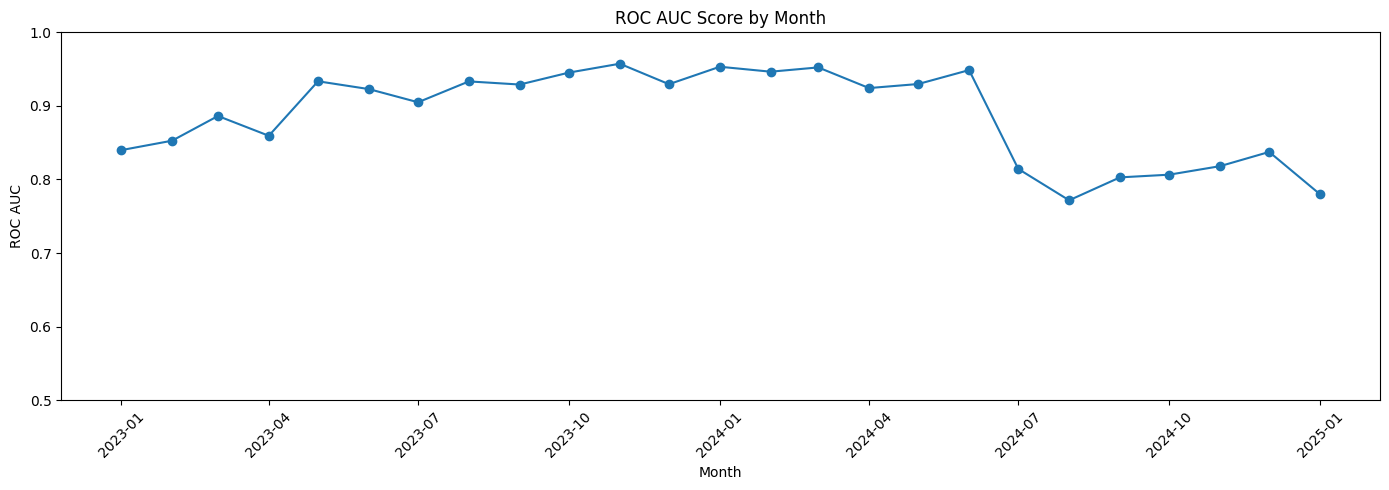

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(auc_by_month['snapshot_date'], auc_by_month['roc_auc'], marker='o')
plt.title('ROC AUC Score by Month')
plt.xlabel('Month')
plt.ylabel('ROC AUC')
plt.xticks(rotation=45)
plt.ylim(0.5, 1)
plt.tight_layout()
plt.show()

In [65]:
# records_month = merged.groupby('snapshot_date').size().reset_index(name='record_count')

In [66]:
# records_month

In [64]:
# get calculate psi and write to a table
train_test_start_date = pd.Timestamp('2023-01-01')
oot_start_date = pd.Timestamp('2024-04-01')
inf_start_date = pd.Timestamp('2024-09-01')

train_test_df = merged[merged['snapshot_date'] < oot_start_date]
oot_df = merged[(merged['snapshot_date'] >= oot_start_date) & (merged['snapshot_date'] < inf_start_date)]
inf_df = merged[merged['snapshot_date'] >= inf_start_date]



In [77]:
# def calculate_psi(reference, comparison, bins=10):
#     # create bins based on reference distribution
#     breakpoints = np.linspace(0, 1, bins + 1)

#     ref_counts, _ = np.histogram(reference, bins=breakpoints)
#     comp_counts, _ = np.histogram(comparison, bins=breakpoints)

#     # convert to proportions, avoid division by zero
#     ref_pct = ref_counts / len(reference)
#     comp_pct = comp_counts / len(comparison)

#     ref_pct = np.where(ref_pct == 0, 1e-4, ref_pct)
#     comp_pct = np.where(comp_pct == 0, 1e-4, comp_pct)

#     psi_values = (comp_pct - ref_pct) * np.log(comp_pct / ref_pct)
#     return psi_values.sum()

def calculate_psi(reference, comparison, bins=10):
    breakpoints = np.quantile(reference, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)

    # clip comparison to reference range so no values are dropped
    comparison = np.clip(comparison, breakpoints[0], breakpoints[-1])

    ref_counts, _ = np.histogram(reference, bins=breakpoints)
    comp_counts, _ = np.histogram(comparison, bins=breakpoints)

    ref_pct = ref_counts / len(reference)
    comp_pct = comp_counts / len(comparison)

    ref_pct = np.where(ref_pct == 0, 1e-4, ref_pct)
    comp_pct = np.where(comp_pct == 0, 1e-4, comp_pct)

    psi_values = (comp_pct - ref_pct) * np.log(comp_pct / ref_pct)
    return psi_values.sum()

In [78]:
# train_test_df.describe()

In [79]:
reference = train_test_df['model_predictions']

psi_oot = calculate_psi(reference, oot_df['model_predictions'])
psi_inf = calculate_psi(reference, inf_df['model_predictions'])

print(f"PSI (OOT):  {psi_oot:.4f}")
print(f"PSI (INF):  {psi_inf:.4f}")

PSI (OOT):  0.0298
PSI (INF):  0.3850


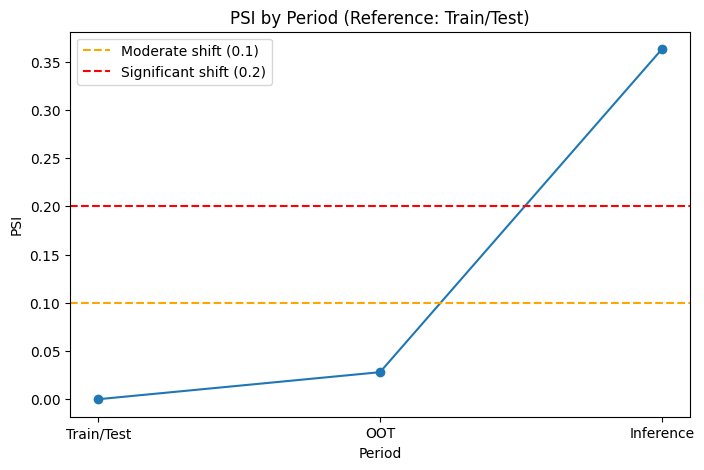

In [70]:
psi_data = {
    'Period': ['Train/Test', 'OOT', 'Inference'],
    'PSI': [
        calculate_psi(reference, train_test_df['model_predictions']),
        psi_oot,
        psi_inf
    ]
}
psi_period_df = pd.DataFrame(psi_data)

plt.figure(figsize=(8, 5))
plt.plot(psi_period_df['Period'], psi_period_df['PSI'], marker='o')
plt.axhline(y=0.1, color='orange', linestyle='--', label='Moderate shift (0.1)')
plt.axhline(y=0.2, color='red', linestyle='--', label='Significant shift (0.2)')
plt.title('PSI by Period (Reference: Train/Test)')
plt.xlabel('Period')
plt.ylabel('PSI')
plt.legend()


In [81]:
date_ls = generate_first_of_month_dates('2023-01-01', '2025-01-01')
    
psi_by_month = []

for date_str in date_ls:
    date_f = pd.Timestamp(date_str)
    temp = merged[merged['snapshot_date'] == date_f]
    psi = calculate_psi(reference, temp['model_predictions'])
    psi_by_month.append({'snapshot_date': date_f, 'psi': psi})

psi_df = pd.DataFrame(psi_by_month)

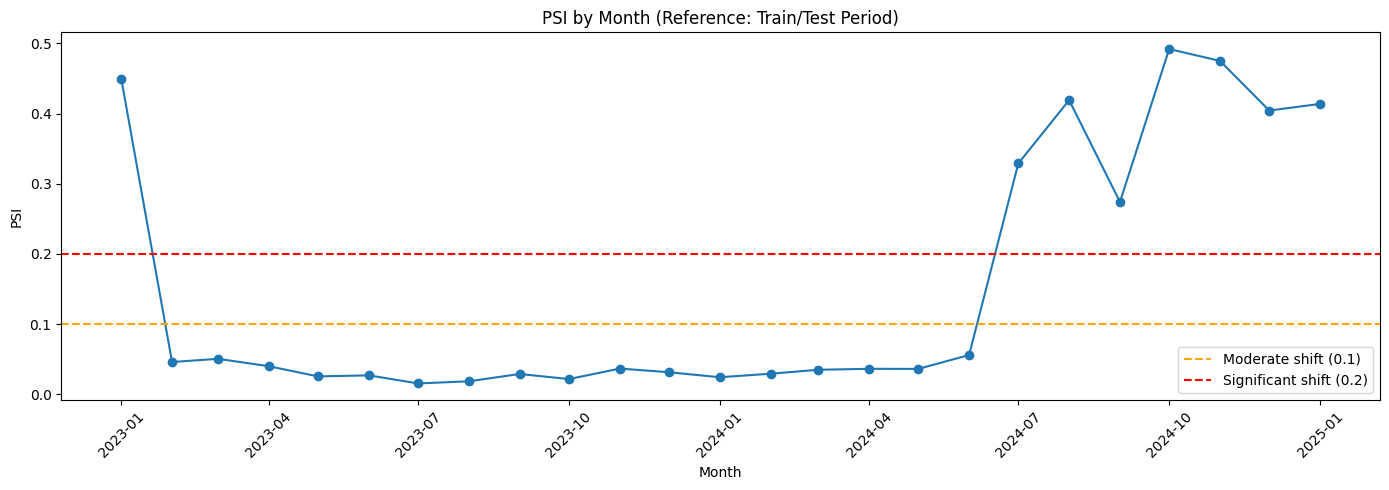

In [82]:
plt.figure(figsize=(14, 5))
plt.plot(psi_df['snapshot_date'], psi_df['psi'], marker='o')
plt.axhline(y=0.1, color='orange', linestyle='--', label='Moderate shift (0.1)')
plt.axhline(y=0.2, color='red', linestyle='--', label='Significant shift (0.2)')
plt.title('PSI by Month (Reference: Train/Test Period)')
plt.xlabel('Month')
plt.ylabel('PSI')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# monthly read for implementing in airflow

## .py file

## .ipynb file - for plotting